In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
MTPLfreq = pd.read_csv('freMTPLfreq.csv')
print('MTPLfreq was loaded.\n')
MTPLsev = pd.read_csv('freMTPLsev.csv')
print('MTPLsev was loaded.\n')

MTPLfreq was loaded.

MTPLsev was loaded.



In [ ]:
MTPLfreq.head()

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
0,1,0,0.09,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76
1,2,0,0.84,g,0,46,Japanese (except Nissan) or Korean,Diesel,Aquitaine,76
2,3,0,0.52,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003
3,4,0,0.45,f,2,38,Japanese (except Nissan) or Korean,Regular,Nord-Pas-de-Calais,3003
4,5,0,0.15,g,0,41,Japanese (except Nissan) or Korean,Diesel,Pays-de-la-Loire,60


In [ ]:
MTPLsev.head()

,PolicyID,ClaimAmount
0,63987,1172
1,310037,1905
2,314463,1150
3,318713,1220
4,309380,55077


In [ ]:
# Checking for total amount of claims paid in original DataFrame, prior to merging MTPLfreq with MTPLsev.
print(sum(MTPLsev['ClaimAmount']))

# Aggregate the claim amounts by PolicyID, prior to merging MTPLfreq with MTPLsev.
MTPLsev_grp = MTPLsev.groupby(['PolicyID'])[['ClaimAmount']].agg('sum').reset_index()

# Performing an outer merge between MTPLfreq/MTPLsev, based on PolicyID, then reset the index back to PolicyID (this is dropped during merging).
df_merged = pd.merge(MTPLfreq, MTPLsev_grp, how='outer', on='PolicyID').fillna(0).set_index('PolicyID')

# Checking for the total amount of claims paid in new DataFrame, after merging MTPLfreq with MTPLsev.
print(sum(df_merged['ClaimAmount']))


34465077
34465077.0


Understanding the meaning of data(columns), then assigning the targets on their dataframes

In [ ]:
#Understanding the column and data types
print(df_merged.columns)
print('\n')
print(df_merged.dtypes)
print('\n')

Index(['ClaimNb', 'Exposure', 'Power', 'CarAge', 'DriverAge', 'Brand', 'Gas',
       'Region', 'Density', 'ClaimAmount'],
      dtype='object')


ClaimNb          int64
Exposure       float64
Power           object
CarAge           int64
DriverAge        int64
Brand           object
Gas             object
Region          object
Density          int64
ClaimAmount    float64
dtype: object




**From the code above, we can see that we have a variety of datatypes within our dataframe - the columns with object dtype contain non-numerical (character) data, which will need to be pre-processed in order for these to be machine-interpretable.**



In [ ]:
#First 5 rows of MTPL dataset
print(df_merged.head())
print('\n')

          ClaimNb  Exposure Power  CarAge  DriverAge  \
PolicyID                                               
1               0      0.09     g       0         46   
2               0      0.84     g       0         46   
3               0      0.52     f       2         38   
4               0      0.45     f       2         38   
5               0      0.15     g       0         41   

                                       Brand      Gas              Region  \
PolicyID                                                                    
1         Japanese (except Nissan) or Korean   Diesel           Aquitaine   
2         Japanese (except Nissan) or Korean   Diesel           Aquitaine   
3         Japanese (except Nissan) or Korean  Regular  Nord-Pas-de-Calais   
4         Japanese (except Nissan) or Korean  Regular  Nord-Pas-de-Calais   
5         Japanese (except Nissan) or Korean   Diesel    Pays-de-la-Loire   

          Density  ClaimAmount  
PolicyID                        
1

**From the code above, we can see a list of the first few rows within the merged dataframe - here, the PolicyID is set as the index, and each row lists out the values of each column (risk feature) for the first 5 policyholders within the dataset.**



*How many policyholders have made zero claims? How will this affect the choice of model that we use to estimate claim severity?



In [ ]:
policies_no_claims = len(df_merged.loc[df_merged['ClaimNb'] == 0].index)
all_policies = len(df_merged.index)

pct_pols_no_clm = round((policies_no_claims/all_policies)*100, 2)

print(str(pct_pols_no_clm)+"% of policyholders have not made any claims.")

96.28% of policyholders have not made any claims.


As a vast majority of the policyholders have not made any claims whatsoever, this implies that ClaimAmount will have a distribution that peaks at zero, but also features right-skewness/tailing to account for positive (total) claim amounts with exponentially decaying probability.

Hence, the linear regression model that we use/choose will need to be able to sufficiently account for both of these characteristics of the distribution of ClaimAmount.



Additional features

Here, we create two new variables based on existing features - these are ClaimFreq and ClaimSev, which represent the frequency and severity of a policyholder's claim/s, respectively, in units of policy exposure. However, one of these features is not appropriate for use in model training.



In [ ]:
df_merged['ClaimFreq'] = df_merged['ClaimNb'] / df_merged['Exposure']

df_merged['ClaimSev'] = df_merged['ClaimAmount'] / df_merged['Exposure']

Next, we will consider where data leakage may be likely to creep into the model fitting process, by reviewing the features/columns to confirm their meanings and evaluate whether any of them can introduce bias into the model training process. In this project, the following two factors are considered to be relevant:

1.Target Leakage:

Happens when features contain information unavailable at
prediction time.
Any feature derived from the target variable (e.g., ClaimSev) must be dropped.
ClaimSev depends on ClaimAmount, which is unknown during prediction.
ClaimNb/ClaimFreq could indicate leakage but is assumed as prior predictions for pure risk premium estimation.

2.Train-Test Contamination:

Occurs when training data is reused for predictions, leading to biased evaluation.
The model may appear to perform well on the test set but struggle with unseen data.
Using train_test_split() ensures proper separation and avoids contamination.

**Perform a train-test split of the dataset**

Next - we will create separate DataFrames that will store the features and target variables. These are then supplied to the sklearn function train_test_split() in order to split the data into training/test subsets, for the reason outlined above.



In [ ]:
# Assign the target variable to its own dataframe.
y_full = df_merged.ClaimAmount

# Assign the features to their own dataframe. Also, remove ClaimSev, to prevent data leakage when predicting ClaimAmount.
X_full = df_merged.drop(['ClaimAmount', 'ClaimSev'], axis=1)

print(y_full.head())

print(X_full.head())

# Perform a train-test split to obtain the training and test data as separate dataframes.
from sklearn.model_selection import train_test_split

# We will set the size of the X/y training datasets to be 80% of the original (full) X/y datasets, via the train_size/test_size parameters
X_train, X_valid, y_train, y_valid = train_test_split(X_full, y_full, train_size=0.8, test_size=0.2, random_state=1)


PolicyID
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: ClaimAmount, dtype: float64
          ClaimNb  Exposure Power  CarAge  DriverAge  \
PolicyID                                               
1               0      0.09     g       0         46   
2               0      0.84     g       0         46   
3               0      0.52     f       2         38   
4               0      0.45     f       2         38   
5               0      0.15     g       0         41   

                                       Brand      Gas              Region  \
PolicyID                                                                    
1         Japanese (except Nissan) or Korean   Diesel           Aquitaine   
2         Japanese (except Nissan) or Korean   Diesel           Aquitaine   
3         Japanese (except Nissan) or Korean  Regular  Nord-Pas-de-Calais   
4         Japanese (except Nissan) or Korean  Regular  Nord-Pas-de-Calais   
5         Japanese (except Nissan) or Korean   Diesel    

**Encoding categorical variable**

**Label Encoding**

Here, we label-encode the Power column such that it changes each (ordinal) text-based label to a numerical value which is machine-interpretable, for later use in feature scaling as well as model fitting

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the training/validation feature subsets to avoid changing any original data.
copy_X_train = X_train.copy()
copy_X_valid = X_valid.copy()

# Apply a label encoder to the 'Power' column (i.e. encoding of ordinal variable).
label_encoder = LabelEncoder()

copy_X_train['Power'] = label_encoder.fit_transform(X_train['Power'])
copy_X_valid['Power'] = label_encoder.transform(X_valid['Power'])

**One-Hot Encoding**

We also one-hot encode the Brand, Gas and Region columns, such that these categories are converted to numerical and machine-interpretable values that can be supplied to each regression model.



In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialise a one-hot encoder to columns that contain categorical data.
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols = ['Brand', 'Gas', 'Region']

## We set handle_unknown='ignore' to avoid errors when the validation data contains classes that aren't represented
## in the training data, and setting sparse=False ensures that the encoded columns are returned as a numpy array
## (instead of a sparse matrix).

# Use the one-hot encoder to transform the categorical data columns.
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(copy_X_train[OH_cols]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(copy_X_valid[OH_cols]))

# One-hot encoding removes the index; re-assign the original index.
OH_cols_train.index = copy_X_train.index
OH_cols_valid.index = copy_X_valid.index

# Add column-labelling back in, using the get_feature_names() function.
OH_cols_train.columns = OH_encoder.get_feature_names_out(OH_cols)
OH_cols_valid.columns = OH_encoder.get_feature_names_out(OH_cols)

# Create copies that only include numerical feature columns (these will be replaced with one-hot encoded versions).
copy_X_train_no_OH_cols = copy_X_train.drop(OH_cols, axis=1)
copy_X_valid_no_OH_cols = copy_X_valid.drop(OH_cols, axis=1)

# Concatenate the one-hot encoded columns with the existing numerical feature columns.
X_train_enc = pd.concat([copy_X_train_no_OH_cols, OH_cols_train], axis=1)
X_valid_enc = pd.concat([copy_X_valid_no_OH_cols, OH_cols_valid], axis=1)


**Data scaling - normalisation**

Next, we perform min-max scaling on the encoded dataset, such that all features lie between 0 and 1 - this is so that, when training any of the regression models, all features will have variances with the same order of magnitude as each other. Thus, no single feature will dominate the objective function and prohibit the model from learning from other features correctly as expected.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialise the MinMaxScaler model, then fit it to the (encoded) training feature dataset.
MM_scaler = MinMaxScaler()
MM_scaler.fit(X_train_enc)

# Fit the scaler, then normalise/transform both the training and validation feature datasets.
X_train_scale = pd.DataFrame(MM_scaler.transform(X_train_enc),
                             index=X_train_enc.index,
                             columns=X_train_enc.columns)

X_valid_scale = pd.DataFrame(MM_scaler.transform(X_valid_enc),
                             index=X_valid_enc.index,
                             columns=X_valid_enc.columns)

**Comparison of X_train_scale and X_valid_scale**

Here, we check to ensure that all feature values are now numerically encoded and are between 0 and 1

In [ ]:
# Verify minimum value of all features in X_train_scale:

X_train_scale.min(axis=0)

,0
ClaimNb,0.0
Exposure,0.0
Power,0.0
CarAge,0.0
DriverAge,0.0
Density,0.0
ClaimFreq,0.0
Brand_Fiat,0.0
Brand_Japanese (except Nissan) or Korean,0.0
"Brand_Mercedes, Chrysler or BMW",0.0


In [ ]:
# Verify maximum value of all features in X_train_scale:

X_train_scale.max(axis=0)

,0
ClaimNb,1.0
Exposure,1.0
Power,1.0
CarAge,1.0
DriverAge,1.0
Density,1.0
ClaimFreq,1.0
Brand_Fiat,1.0
Brand_Japanese (except Nissan) or Korean,1.0
"Brand_Mercedes, Chrysler or BMW",1.0


In [ ]:
# Verify minimum value of all features:

X_valid_scale.min(axis=0)

,0
ClaimNb,0.0
Exposure,0.0
Power,0.0
CarAge,0.0
DriverAge,0.0
Density,0.0
ClaimFreq,0.0
Brand_Fiat,0.0
Brand_Japanese (except Nissan) or Korean,0.0
"Brand_Mercedes, Chrysler or BMW",0.0


In [ ]:
# Verify maximum value of all features:

X_valid_scale.max(axis=0)

,0
ClaimNb,1.000000
Exposure,0.718206
Power,1.000000
CarAge,1.000000
DriverAge,1.000000
Density,1.000000
ClaimFreq,1.000000
Brand_Fiat,1.000000
Brand_Japanese (except Nissan) or Korean,1.000000
"Brand_Mercedes, Chrysler or BMW",1.000000


**Explore the original dataset to obtain descriptive statistics**

Here, we use the pd.describe() function to obtain descriptive statistics of the original dataset (prior to preprocessing).



In [ ]:
print(df_merged.describe())

             ClaimNb       Exposure         CarAge      DriverAge  \
count  413169.000000  413169.000000  413169.000000  413169.000000   
mean        0.039163       0.561088       7.532404      45.319876   
std         0.204053       0.369477       5.763011      14.328120   
min         0.000000       0.002732       0.000000      18.000000   
25%         0.000000       0.200000       3.000000      34.000000   
50%         0.000000       0.540000       7.000000      44.000000   
75%         0.000000       1.000000      12.000000      54.000000   
max         4.000000       1.990000     100.000000      99.000000   

             Density   ClaimAmount      ClaimFreq      ClaimSev  
count  413169.000000  4.131690e+05  413169.000000  4.131690e+05  
mean     1985.153913  8.341642e+01       0.118803  3.711403e+02  
std      4776.254543  4.192526e+03       2.155181  3.493029e+04  
min         2.000000  0.000000e+00       0.000000  0.000000e+00  
25%        67.000000  0.000000e+00       0.00000

Next, we will generate pairplots between the targets and features to understand the relationships between them and discover whether there are any trends/correlations within the data. To do this, we will use the seaborn.pairplot() function as a high-level interface to plot the pairwise relationships in the df_merged dataset.

First, we define two separate lists of x-variables that we will produce pairplots with, depending on which y-variable we choose.

In [ ]:
desc_pairplot_x_vars_A = ['ClaimNb', 'Power', 'CarAge', 'DriverAge', 'Brand', 'Gas', 'Density']
desc_pairplot_x_vars_B = ['Power', 'CarAge', 'DriverAge', 'Brand', 'Gas', 'Density']

Next, we supply 3 values to this function's parameters:

1.data - positional argument:

Here, we supply df_merged as a pandas.DataFrame object, where each column is a variable and each row is an observation.

2.x_vars - keyword argument:

Here, we provide the lists of variable names (defined above) as the columns/x-axes of the pairplot figures in order to make the non-square plots.

3.y_vars - keyword argument:

Here, we provide a single variable name (e.g. ClaimNb) as the row/y-axis for each pairplot figure.

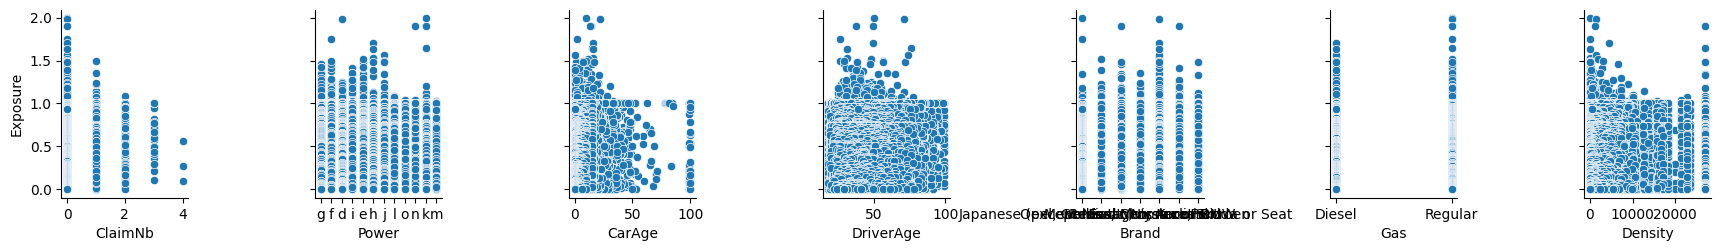

In [ ]:
# Pairplot 1 - Exposure vs. x_vars.

desc_pairplot_1 = sns.pairplot(df_merged, x_vars=desc_pairplot_x_vars_A, y_vars='Exposure')

1.ClaimNb: The trend in this graph implies that policyholders with higher claim frequencies tend to be covered on policies with shorter exposure periods (this view may, however, be affected by renewals/binders).

2.Power: The trend in this graph implies that cars covered by policies with longer exposure periods tend to be less powerful, although there appear to be some high-powered cars (e.g. categories k/n) that go against this pattern.

3.CarAge: The trend in this graph implies that a vast majority of the cars insured have 1-year exposure periods, with a wider spread of policy exposure periods in the range of years lower than 25 (i.e. relatively young cars).

4.DriverAge: This graph shows a wide distribution of exposure periods across drivers of different ages, with a range of middle-aged policyholders that are insured with exposure periods longer than 1 year.

5.Brand: This graph does not show any clear correlation or trend between the exposure period of the MTPL policy and the brand of the car that is insured.

6.Gas: This graph does not show any clear correlation or trend between the exposure period of the MTPL policy and the fuel type of the car that is insured.

7.Density: This graph shows a wide distribution of policy exposure periods, which appears to decrease as the population density of the area that the policyholder inhabits increases; however, this distribution does feature some observations at higher values of Density.

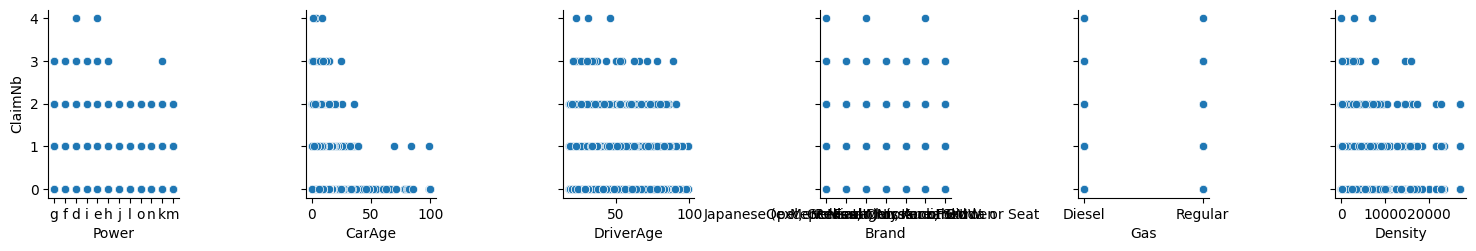

In [ ]:
# Pairplot 2 - ClaimNb vs. x_vars.

desc_pairplot_2 = sns.pairplot(df_merged, x_vars=desc_pairplot_x_vars_B, y_vars='ClaimNb')

1.Power: The trend in this graph implies that policyholders who are in the upper quartile of claim frequency (i.e. N > 3) tend to drive less powerful/average cars, however there does not appear to be any general correlation between car power and claim frequency, among the majority of other policyholders.

2.CarAge: The trend in this graph implies that a majority of the variance in ClaimNb is shown across cars that are younger than 50; the number of claims per policyholder tends to decrease with the age of the car.

3.DriverAge: This graph shows a wide distribution of claim frequencies across drivers of different ages, with no clear trend between the age of the policyholder and the number of claims that they have made.

4.Brand: This graph does not show any clear correlation or trend between the number of claims made and the brand of the car owned by the (insured) policyholder.

5.Gas: This graph also does not show any clear correlation between the number of claims made and the fuel type of the car that is insured.

6.Density: This graph shows the general trend that the number of claims per policyholder decreases as the population density (of the town/city that they live in) increases.

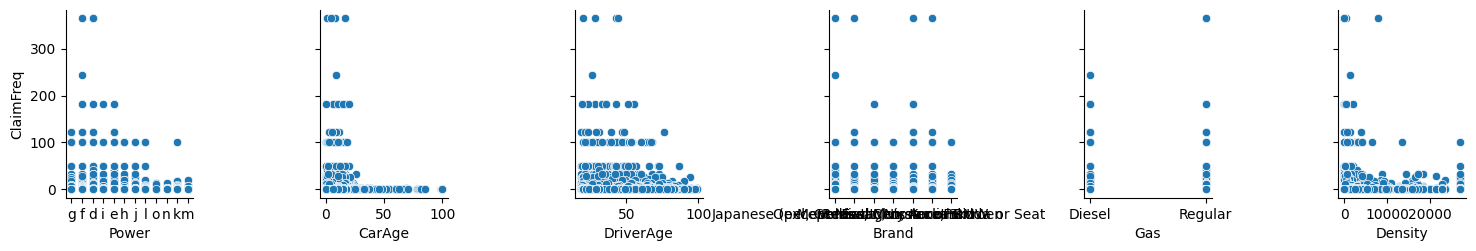

In [ ]:
# Pairplot 3 - ClaimFreq vs. x_vars (i.e. accounting for policy exposure weighting).

desc_pairplot_3 = sns.pairplot(df_merged, x_vars=desc_pairplot_x_vars_B, y_vars='ClaimFreq')

1.Power: The trend in this graph implies that ClaimFreq tends to decrease as the power of the car increases, however there are also some small peaks in ClaimFreq for certain categories representing high-powered cars (e.g. k/l).

2.CarAge: This graph shows that a vast majority of the variance in ClaimFreq is shared across policyholders who own relatively young cars (CarAge < 25), but also implies that ClaimFreq decreases as the age of the car increases.

3.DriverAge: This graph shows that claim frequency also decreases as the age of the policyholder increases, however a vast majority of the variance in ClaimFreq can be captured between the values of 0-100 (across all driver ages).

4.Brand: There appears to be no clear trend or correlation between the frequency of claims and the brand of the car owned by the policyholder.

5.Gas: This graph also does not show any clear correlation between ClaimFreq and the fuel type of the policyholder's car.

6.Density: This graph displays a negative correlation between the frequency of claims made by the policyholder and the population density of the city that they live in

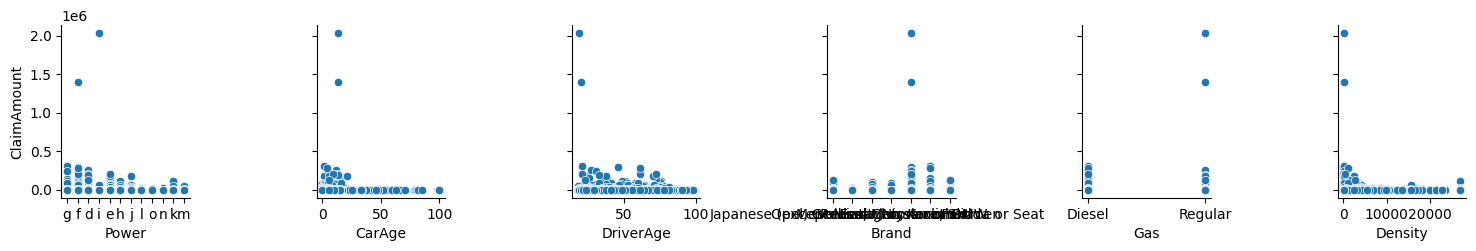

In [ ]:
# Pairplot 4 - ClaimAmount vs. x_vars.

desc_pairplot_4 = sns.pairplot(df_merged, x_vars=desc_pairplot_x_vars_B, y_vars='ClaimAmount')

1.Power: This graph shows that there is an overall negative correlation between the power of the car owned by the policyholder and the total value of claims made by them, however there are two major outliers at lower car powers - this is generally an exception to the rule.

2.CarAge: Similarly to the power of the car, there is an overall negative correlation between the age of the car and the total value of claims made by the policyholder, however there are some outliers for relatively new cars.

3.DriverAge: This graph shows that total claim amounts tend to be higher at younger ages (between 20-40), however there is also a smaller group of drivers between 60-80 that are responsible for non-trivial total claim amounts; major outliers can also be seen for two newer drivers (DriverAge ~ 20).

4.Brand: Whilst there are a handful of brands that are responsible for higher-than-normal claim amounts, these are in the vast minority of policyholders - the overall trend is that there is no clear correlation between the brand of the car and the total claim amount.

5.Gas: This graph also does not show any clear correlation between ClaimAmount and the fuel type of the policyholder's car, however there are two distinct outliers within the 'Regular' category.

6.Density: This graph displays a negative correlation between the total value of claims made by the policyholder and the population density of the city that they live in

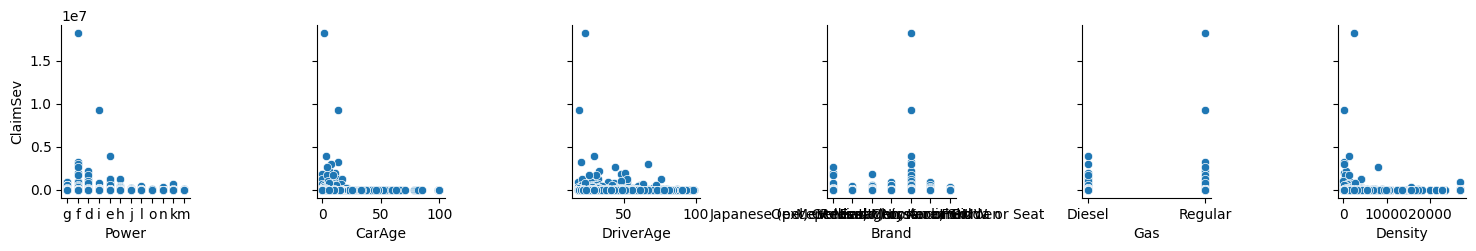

In [ ]:
# Pairplot 5 - ClaimSev vs. x_vars (i.e. accounting for policy exposure weighting).

desc_pairplot_5 = sns.pairplot(df_merged, x_vars=desc_pairplot_x_vars_B, y_vars='ClaimSev')

1.Power: This graph shows that there is an overall negative correlation between the power of the car owned by the policyholder and the exposure-weighted total severity of claims made, however as before there are two major outliers at lower car powers.

2.CarAge: Similarly to the power of the car, there is an overall negative correlation between the age of the car and the exposure-weighted total severity of claims made by the policyholder, however there are some outliers for relatively new (albeit slightly used) cars.

3.DriverAge: This graph shows that exposure-weighted claim severities tend to be higher at younger ages (between 20-35), however there is also a smaller group of drivers between 45-55 that are responsible for non-trivial total claim amounts; some major outliers can also be seen for two very new drivers (DriverAge ~ 20).

4.Brand: Whilst there are a handful of brands that are responsible for higher-than-normal claim severities, these are in the vast minority of policyholders - the overall trend is that there is no clear correlation between the brand of the car and the total claim amount.

5.Gas: This graph also does not show any clear correlation between ClaimSeverity and the fuel type of the policyholder's car, however there are two distinct outliers within the 'Regular' category.

6.Density: This graph displays a negative correlation between the total value of claims made by the policyholder and the population density of the city that they live in.

**Performing feature selection via L1**

Next, we will perform feature selection via L1 (lasso) regularisation, in order to reduce the number of features that are used for fitting each of the models - this is done in order to prevent overfitting.

Next, we will pass lasso to the SelectFromModel class, before assigning it to a new variable called model - we specify prefit=True to ensure that the meta-transformer should expect a prefit model to be passed directly to it.

Then, we apply the .transform() method in order to reduce the scaled training dataset down to the features that were selected by the Lasso (regression) model.

Finally, we create a new dataframe selected_features which holds all 'important' features from the original set of columns in X_train_l1 as their original (scaled) values, but sets values of 0 for every other feature.



In [ ]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Establish the Lasso (L1) Regularisation model that will perform feature selection.
lasso = Lasso(alpha=5e-5, random_state=1, max_iter=1000000).fit(X_train_scale, y_train)
model = SelectFromModel(lasso, prefit=True)

X_train_l1 = model.transform(X_train_scale)

selected_features = pd.DataFrame(model.inverse_transform(X_train_l1),
                                index=X_train_scale.index,
                                columns=X_train_scale.columns)

print(selected_features)

          ClaimNb  Exposure     Power  CarAge  DriverAge   Density  ClaimFreq  \
PolicyID                                                                        
194119       0.00  0.240163  0.181818    0.07   0.407407  0.152826   0.000000   
293687       0.00  0.501829  0.272727    0.13   0.358025  0.004667   0.000000   
132615       0.25  0.199907  0.090909    0.09   0.333333  1.000000   0.006849   
138539       0.00  0.290483  0.090909    0.04   0.172840  0.029632   0.000000   
217750       0.00  0.260291  0.181818    0.11   0.111111  0.018631   0.000000   
...           ...       ...       ...     ...        ...       ...        ...   
73350        0.00  0.501829  0.181818    0.09   0.567901  0.002630   0.000000   
371404       0.00  0.209971  0.545455    0.01   0.111111  1.000000   0.000000   
312202       0.00  0.189842  0.000000    0.01   0.481481  1.000000   0.000000   
267337       0.00  0.089202  0.000000    0.12   0.456790  0.005223   0.000000   
128038       0.00  0.501829 

In [ ]:
selected_columns = selected_features.columns[selected_features.var() != 0]

print(selected_columns)

Index(['ClaimNb', 'Exposure', 'Power', 'CarAge', 'DriverAge', 'Density',
       'ClaimFreq', 'Brand_Fiat', 'Brand_Japanese (except Nissan) or Korean',
       'Brand_Mercedes, Chrysler or BMW', 'Brand_Opel, General Motors or Ford',
       'Brand_Renault, Nissan or Citroen', 'Brand_other', 'Gas_Diesel',
       'Region_Aquitaine', 'Region_Basse-Normandie', 'Region_Bretagne',
       'Region_Centre', 'Region_Haute-Normandie', 'Region_Limousin',
       'Region_Nord-Pas-de-Calais', 'Region_Pays-de-la-Loire',
       'Region_Poitou-Charentes'],
      dtype='object')


In [ ]:
X_train_L1reg = selected_features.drop(selected_features.columns[selected_features.var() == 0], axis=1)

print(X_train_L1reg)

          ClaimNb  Exposure     Power  CarAge  DriverAge   Density  ClaimFreq  \
PolicyID                                                                        
194119       0.00  0.240163  0.181818    0.07   0.407407  0.152826   0.000000   
293687       0.00  0.501829  0.272727    0.13   0.358025  0.004667   0.000000   
132615       0.25  0.199907  0.090909    0.09   0.333333  1.000000   0.006849   
138539       0.00  0.290483  0.090909    0.04   0.172840  0.029632   0.000000   
217750       0.00  0.260291  0.181818    0.11   0.111111  0.018631   0.000000   
...           ...       ...       ...     ...        ...       ...        ...   
73350        0.00  0.501829  0.181818    0.09   0.567901  0.002630   0.000000   
371404       0.00  0.209971  0.545455    0.01   0.111111  1.000000   0.000000   
312202       0.00  0.189842  0.000000    0.01   0.481481  1.000000   0.000000   
267337       0.00  0.089202  0.000000    0.12   0.456790  0.005223   0.000000   
128038       0.00  0.501829 

In [ ]:
# The X_valid dataframe is truncated such that only the L1-selected features are used for validation purposes.
X_valid_L1reg = X_valid_scale[selected_columns]

**Defining the models used in the project**

In this project, we aim to predict the target (ClaimAmount) using the following linear regression approaches:

1.Random Forest Regression
Random Forest Regression works by training multiple decision trees, based on the random sampling (with replacement) of a training dataset. Input features from an unseen dataset can then be supplied to each trained decision tree in order to generate a prediction, which is subsequently averaged across all predictions to produce a final regression output; averaging across all predictions has the benefit of reducing overfitting to any given random sample within the training set.


2.Poisson (GLM) Regression
Poisson Regression works in a very similar way to ordinary linear regression, except here we assume that the response variable (ClaimAmount) has a Poisson distribution - thus forming one of two generalised linear models (GLMs) that we will use in this project:

Y
i
i
i
d
∼
P
o
i
s
(
λ
)


This model is chosen purely as the first example of a GLM with a positive continuous distribution that can be used to predict claim severity, although there are better alternatives to use.

3.Tweedie (GLM) Regression
Tweedie Regression, like Poisson regression, also assumes that the response variable follows a non-normal distribution - in this case, we assume that ClaimAmount has a Tweedie distribution:

Y
=
T
∑
i
=
1

X
i
,
T
∼
P
o
i
s
(
λ
)
,
X
i
i
i
d
∼
G
a
(
α
,
γ
)
,
T
⊥
X
i


Where  
Y
  is the aggregate claim amount for a covered risk,  
T
  is the number of reported claims and  
X
i
  is the insurance payment for the  
i
t
h
  claim.

However, the Tweedie distribution is special in that it is an example of a compound Poisson-Gamma distribution, which means that the distribution shows a mix between both Poisson and Gamma form. The Poisson component helps to account for the large positive mass at zero (i.e. where ClaimAmount is 0, as most policyholders do not make any claims), however the Gamma component allows for a continuous, positively skewed, tail-shaped distribution associated with exponentially decaying probability density (i.e. higher claim severities can also be accounted for).

4.XGBoost (eXtreme Gradient Boosting) Regression
XGBoost Regression works similarly to random forest regression, however it is based on an iterative process of gradually reducing the error between predicted & true values. This is achieved by building a new decision tree to fit on the pseudo-residuals of the previous tree, allowing the algorithm to "learn" and iteratively refine the regression model until the objective loss function is sufficiently minimised. This can be performed using gradient descent optimisation algorithms; XGBoost is one example of a gradient descent method, and is widely implemented due to its effectiveness in this context

**Performing cross-validation to obtain the optimal set of hyperparameters for each model**


Here, we will perform 5-fold cross-validation in order to optimise one of each models' hyperparameters. These are:

1.RandomForestRegressor

n_estimators represents the number of decision trees that are implemented by the random forest regressor. We will aim to optimise this hyperparameter.
random_state sets the random number seed and is used for reproducibility purposes. Here, we set this value to 1.
n_jobs represents the number of calculations to run in parallel; setting a value of -1 means that all processors will be used.

2.PoissonRegressor

alpha represents the constants that multiplies the penalty term, thus determining the strength of regularisation for the Poisson GLM used. We will aim to optimise this hyperparameter.
max_iter represents the maximal number of iterations for the PoissonRegressor's solver.

3.TweedieRegressor

power determines the underlying target value's distribution - using a value between 1 and 2 produces a compound Poisson-Gamma distribution.
As a pure Gamma distribution's probability density is not defined at x=0, we set this value to 1.8 such that the target's compound distribution shows more Gamma form than Poisson. This is another hyperparameter that could potentially be optimised for simultaneously, via grid-search methods.

alpha represents the constants that multiplies the penalty term, thus determining the strength of regularisation for the Tweedie GLM used. We will aim to optimise this hyperparameter.
max_iter represents the maximal number of iterations for the TweedieRegressor's solver.

4.XGBRegressor

n_estimators represents the number of gradient boosted trees implemented by the eXtreme Gradient Boosting (XGB) regressor; this is equivalent to the number of boosting rounds. We will aim to optimise this hyperparameter.
learning_rate refers to the boosting learning rate/step size of the XGB regressor - this value is between 0 and 1.
random_state sets the random number seed and is used for reproducibility purposes. Here, we set this value to 1.

In [ ]:
# Import the regression models from sklearn/xgboost.
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.linear_model import TweedieRegressor
from xgboost import XGBRegressor

# Import the cross_val_score function from sklearn.
from sklearn.model_selection import cross_val_score

In [ ]:
## Define scoring functions for each method.

def get_score_RF(n_estimators):
    model_RF = RandomForestRegressor(n_estimators=n_estimators, random_state=1, n_jobs=-1)

    scores_RF = -1 * cross_val_score(model_RF, X_train_L1reg, y_train,
                              cv=5,
                              scoring='neg_mean_absolute_error')

    return scores_RF.mean()


def get_score_PGLM(alpha):
    model_PGLM = PoissonRegressor(alpha=alpha, max_iter=500)

    scores_PGLM = -1 * cross_val_score(model_PGLM, X_train_L1reg, y_train,
                                  cv=5,
                                  scoring='neg_mean_absolute_error')

    return scores_PGLM.mean()


def get_score_TGLM(alpha):
    model_TGLM = TweedieRegressor(power=1.8, alpha=alpha, max_iter=500)

    scores_TGLM = -1 * cross_val_score(model_TGLM, X_train_L1reg, y_train,
                                  cv=5,
                                  scoring='neg_mean_absolute_error')

    return scores_TGLM.mean()


def get_score_XGB(n_estimators):
    model_XGB = XGBRegressor(n_estimators=n_estimators,
                               learning_rate=0.01,
                               random_state=1)

    scores_XGB = -1 * cross_val_score(model_XGB, X_train_L1reg, y_train,
                                     cv=5,
                                     scoring='neg_mean_absolute_error')

    return scores_XGB.mean()


## Create empty dictionaries which will be used to store the scoring results for each method.

results_RF = {}
results_PGLM = {}
results_TGLM = {}
results_XGB = {}

In [ ]:
## Obtain 8 scores for the RandomForestRegressor model.

for i in range(1, 9):
    results_RF[100*i] = get_score_RF(100*i)
    print("results_RF{} recorded".format(i))

print("RF done")

results_RF1 recorded
results_RF2 recorded
results_RF3 recorded
results_RF4 recorded
results_RF5 recorded
results_RF6 recorded
results_RF7 recorded
results_RF8 recorded
RF done


In [ ]:
## Obtain 8 scores for the PoissonRegressor model.

for i in range(1, 9):
    results_PGLM[round(0.2*i, 2)] = get_score_PGLM(round(0.2*i, 2))
    print("results_PGLM{} recorded".format(i))

print("PGLM done")

results_PGLM1 recorded
results_PGLM2 recorded
results_PGLM3 recorded
results_PGLM4 recorded
results_PGLM5 recorded
results_PGLM6 recorded
results_PGLM7 recorded
results_PGLM8 recorded
PGLM done


In [ ]:
## Obtain 8 scores for the TweedieRegressor model.

for i in range(1, 9):
    results_TGLM[round(0.01*i, 2)] = get_score_TGLM(round(0.01*i, 2))
    print("results_TGLM{} recorded".format(i))

print("TGLM done")

results_TGLM1 recorded
results_TGLM2 recorded
results_TGLM3 recorded
results_TGLM4 recorded
results_TGLM5 recorded
results_TGLM6 recorded
results_TGLM7 recorded
results_TGLM8 recorded
TGLM done


In [ ]:
!pip install --upgrade scikit-learn==1.2.2
!pip install --upgrade xgboost<=1.7.5


/bin/bash: line 1: =1.7.5: No such file or directory


In [ ]:
## Obtain 8 scores for the XGBRegressor model.

for i in range(1, 9):
    results_XGB[5*i] = get_score_XGB(5*i)
    print("results_XGB{} recorded".format(i))

print("XGB done")

results_XGB1 recorded
results_XGB2 recorded
results_XGB3 recorded
results_XGB4 recorded
results_XGB5 recorded
results_XGB6 recorded
results_XGB7 recorded
results_XGB8 recorded
XGB done


Defining the optimal parameters

In [ ]:
RF_n_estimators_best = min(results_RF, key=results_RF.get)
print(RF_n_estimators_best)

700


In [ ]:
PGLM_alpha_best = min(results_PGLM, key=results_PGLM.get)
print(PGLM_alpha_best)

0.8


In [ ]:
TGLM_alpha_best = min(results_TGLM, key=results_TGLM.get)
print(TGLM_alpha_best)

0.04


In [ ]:
XGB_n_estimators_best = min(results_XGB, key=results_XGB.get)
print(XGB_n_estimators_best)

40


**Training the models to the entire training dataset**

In [ ]:
# Define the optimised regression models that will be used.

model_RF_opt = RandomForestRegressor(n_estimators=RF_n_estimators_best, random_state=1, n_jobs=-1)

model_PGLM_opt = PoissonRegressor(alpha=PGLM_alpha_best, max_iter=500)

model_TGLM_opt = TweedieRegressor(power=1.8, alpha=TGLM_alpha_best, max_iter=500)

model_XGB_opt = XGBRegressor(n_estimators=XGB_n_estimators_best, learning_rate=0.01, random_state=1)

In [ ]:
# Fit the optimised models to the full (pre-processed) training dataset.

model_RF_opt.fit(X_train_L1reg, y_train)
print("model_RF_opt trained")

model_PGLM_opt.fit(X_train_L1reg, y_train)
print("model_PGLM_opt trained")

model_TGLM_opt.fit(X_train_L1reg, y_train)
print("model_TGLM_opt trained")

model_XGB_opt.fit(X_train_L1reg, y_train)
print("model_XGB_opt trained")

model_RF_opt trained
model_PGLM_opt trained
model_TGLM_opt trained
model_XGB_opt trained


**Generating a unique set of predictions for each model**

The next step is to generate predictions of ClaimAmount for each policyholder within the pre-processed validation dataset; this is done using the .predict() function for each of the optimised models.


In [ ]:
# Use the trained models to generate unique sets of predicted y-values i.e. ClaimAmount.

preds_RF = model_RF_opt.predict(X_valid_L1reg)
preds_PGLM = model_PGLM_opt.predict(X_valid_L1reg)
preds_TGLM = model_TGLM_opt.predict(X_valid_L1reg)
preds_XGB = model_XGB_opt.predict(X_valid_L1reg)
print("All predictions generated")

All predictions generated


 **Assessing the chosen models' performance, using validation data**


In order to evaluate and rank the models based on their regression performances, an appropriate scoring metric should be used. One common example of this is to calculate the Mean Absolute Error (MAE) for each of the fitted models against the validation data, which can then be ranked in order to determine the model with the lowest MAE, which is deemed to be the best model in terms of accuracy and goodness of fit:

MAE
=
1
n
n
∑
t
=
1

|
e
t
|


Alternatively, the Root Mean Squared Error (RMSE) can be derived for each fitted model against the validation data:

RMSE
=
√
1
n
n
∑
t
=
1

e
2
t


However, in order to calculate the RMSE of a model, each prediction error must be squared before they are averaged together; this means that larger errors/outliers are more strongly penalised than smaller errors. Therefore, as the vast majority (~96%) of policyholders within the freMTPL dataset have not made any claims whatsoever, we do not wish to heavily penalise each of the models based on any severe claims/outliers that are incorrectly predicted, as this would increase the risk of overfitting each model to these outliers (i.e. by encouraging the model to predict large claims more frequently).

Hence, we will use the mean_absolute_error() function from sklearn.metrics to calculate the MAE score, comparing each model's predictions against the validation dataset's (true) values.



In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate the Mean Absolute Error metric for each set of predicted y-values.

MAE_RF = mean_absolute_error(y_valid, preds_RF)
MAE_PGLM = mean_absolute_error(y_valid, preds_PGLM)
MAE_TGLM = mean_absolute_error(y_valid, preds_TGLM)
MAE_XGB = mean_absolute_error(y_valid, preds_XGB)
print("All MAE scores calculated")

All MAE scores calculated


**Evaluating the models' performance**

Finally, we can determine the most effective model as the one that has obtained the lowest MAE.


In [ ]:
# Collect all MAE scores in a single dictionary.

MAE_results = {'RF': MAE_RF,
                'PGLM': MAE_PGLM,
                'TGLM': MAE_TGLM,
                'XGB': MAE_XGB}

print(MAE_results)

{'RF': 95.01813166443816, 'PGLM': 119.4755773018888, 'TGLM': 77.99906852382604, 'XGB': 111.27960643998668}


In [ ]:
# Select the model with the smallest MAE.

best_model = min(MAE_results, key=MAE_results.get)
print(best_model)

TGLM
